# Price European options using Monte Carlo integration
**Apply Fire Opal's MCI function to financial modeling**

Expectation value estimation over a stochastic process is a computational task where the objective is to evaluate the mean outcome of a system governed by underlying probability distributions. 
It arises in a wide range of real-world applications, including derivative pricing, portfolio risk modeling, and chemical reaction dynamics. 
One example is European option pricing, where estimating the expected payoff of an option contract at maturity requires evaluating an integral over a price distribution—a task ideally suited for Monte Carlo integration on quantum devices.
In this application note, we demonstrate how to price a European option using Fire Opal's MCI function, allowing practitioners to compute high-precision expected values without requiring low-level circuit compilation expertise.

We demonstrate the workflow on instances with directly calculable classical references. This notebook covers the following:

* An introduction to Monte Carlo integration
* An introduction to European option pricing 
* Hardware demonstrations employing Fire Opal's Monte Carlo function using (1) quantum circuit construction, and (2) high-level finance helper functions

***
*Some cells in this notebook require an account with IBM Quantum Platform to execute correctly. If you want to run them, please go to the [IBM Quantum Platform](https://quantum.cloud.ibm.com/) to set up an account.*
***

## 1. Introduction to Monte Carlo integration

Monte Carlo integration is widely used to estimate the expected values of complex random processes across many fields such as chemistry, biology, finance, and cryptography. 
For example, in finance, Monte Carlo methods are fundamental for pricing derivatives, computing Value-at-Risk (VaR), and assessing portfolio risks. 
However, Monte Carlo approaches converge to the true expected value relatively slowly. 
To reduce the error in the estimate by one decimal place, the number of samples must be increased by a factor of 100X. 
This means a large number of samples are required to drive the error sufficiently low, and makes high-precision estimates costly in time and resources.
To mitigate this cost, a wide array of variance reduction techniques (such as importance sampling and control variates) have been extensively studied and applied. 
These methods aim to lower the variance of estimators and therefore reduce the number of required samples without compromising accuracy.

Quantum computing adds a unique and compelling contribution to this toolbox. 
Specifically, quantum amplitude estimation (QAE), a quantum algorithm based on amplitude amplification, provides a quadratic improvement in the convergence rate of Monte Carlo integration. 
Rather than 100X more samples to reduce the error of the expected value by one decimal place, only 10X more samples are needed. 
For applications where accuracy and speed are critical, QAE has the potential to be a valuable addition to the set of tools available to practitioners seeking to improve the performance of expected value estimation, both in finance and beyond.

### 1.1 How Fire Opal solves execution challenges

The traditional QAE implementation requires the use of [quantum phase estimation](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/improve-the-results-of-quantum-phase-estimation).
Modern QAE variants replace phase estimation with sequences of shallower circuits combined with classical post-processing. 
Fire Opal's approach leverages Quantum Signal Processing (QSP) for amplitude estimation, which reduces circuit depth and ancilla qubit requirements. 
It preserves the core advantage of quantum quadratic speedup while significantly reducing the quantum hardware requirements, making interesting problems tractable on near-term quantum devices. 
Fire Opal's core error suppression workflow also enhances circuit deployment performance, protecting QSP phase signals to enable reliable, high-fidelity convergence to true expectation values on physical quantum hardware.

## 2. Introduction to European option pricing 

European options are among the most fundamental financial derivatives in quantitative risk management and trading. 
A European option grants the holder the right to buy or sell an underlying asset at a predetermined strike price on a specific expiration date. 
To determine the fair market price of an option today, quantitative models calculate the expected payoff at maturity under a modeled probability distribution of future asset prices (typically a log-normal distribution), and discount that value back to the present day. 

In this demonstration, we consider a European digital range option.
Instead of having a payoff that changes continuously with the asset price, a digital range option yields a fixed binary payoff based on whether the asset price finishes inside a target strike window:
* Payoff = 1: If the asset price at maturity ($S_T$) falls within the strike window ($K_{\text{low}} \le S_T \le K_{\text{high}}$).
* Payoff = 0: If the asset price finishes outside the strike window.

Pricing this option requires evaluating the expected payoff, which is equivalent to calculating the probability that the final asset price lands within the strike window under a modeled log-normal price distribution. 

For implementation convenience and to allow a closed-form option price calculation for comparison, we model the asset price at maturity directly using a log-normal distribution and define the strike window to be between the 50-75th percentile of possible stock prices with respect to the price-at-maturity distribution.
This simple example serves as a representative use case for quantum amplitude estimation in finance, and provides a benchmark for evaluating the performance of our Monte Carlo function.

## 3. Imports and initialization
Install the required packages in the active notebook environment. Restart the kernel after installation when necessary.

In [ ]:
# %pip install fire-opal qiskit_ibm_runtime qiskit qiskit-finance scipy matplotlib numpy qctrl-visualizer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
from scipy.integrate import quad
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.qasm2 import dumps
import qctrlvisualizer as qv
import fireopal as fo
from qctrlvisualizer import QCTRL_STYLE_COLORS
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from qctrlvisualizer.utils import create_figure
from qctrlvisualizer.style import qctrl_style
from qiskit_finance.circuit.library import LogNormalDistribution


plt.style.use(qv.get_qctrl_style())

import warnings

warnings.filterwarnings("ignore")

In [ ]:
# Authenticate your Q-CTRL account.
api_key = "YOUR_Q-CTRL_API_KEY"
fo.authenticate_qctrl_account(api_key=api_key)

token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

# Replace with a backend available to your IBM Quantum instance.
backend_name = "desired_backend"

## 4. Defining and visualizing the pricing problem

Here, we characterize a European digital range option.
The parameters determine the problem size, and the final spot price distribution.
This distribution is used to obtain maximum and minimum price values (the high and low), and we highlight that the strike window is selected dynamically (within the user-defined price distribution) to enable a low-depth quantum oracle (or marker) circuit.
More general strike windows or thresholds can be selected, noting that deeper circuits are more susceptible to hardware errors.

We also plot the probability distribution and payoff function corresponding to the spot price at maturity.
The tick markers and grid display the discretized price values represented by the qubits; the grid is finer with more data qubits.

In [2]:
@dataclass
class EuropeanOptionPricing:
    spot_price: float
    volatility: float
    interest_rate: float
    maturity_years: float

    @property
    def mu(self) -> float:
        return (
            self.interest_rate - 0.5 * self.volatility**2
        ) * self.maturity_years + np.log(self.spot_price)

    @property
    def sigma(self) -> float:
        return self.volatility * np.sqrt(self.maturity_years)

    @property
    def mean(self) -> float:
        return np.exp(self.mu + self.sigma**2 / 2)

    @property
    def variance(self) -> float:
        return (np.exp(self.sigma**2) - 1) * np.exp(2 * self.mu + self.sigma**2)

    @property
    def stddev(self) -> float:
        return np.sqrt(self.variance)

    def get_high_low(self) -> tuple[float, float]:
        low = round(np.maximum(0, self.mean - 3 * self.stddev), 3)
        high = round(self.mean + 3 * self.stddev, 3)
        return high, low

    def get_strike_window(self) -> tuple[float, float]:
        high, low = self.get_high_low()

        strike_low = (high - low) / 2 + low
        strike_high = (high - low) / 4 + strike_low

        strike_window = (strike_low, strike_high)

        return strike_window

    def get_uncertainty_model(self, num_qubits: int) -> LogNormalDistribution:
        high, low = self.get_high_low()
        uncertainty_model = LogNormalDistribution(
            num_qubits=num_qubits, mu=self.mu, sigma=self.sigma**2, bounds=(low, high)
        )
        return uncertainty_model

    def get_exact_solution(self, return_error: bool = False):
        def lognormal_pdf(x, mu, sigma):
            if x <= 0:
                return 0
            return (1 / (x * sigma * np.sqrt(2 * np.pi))) * np.exp(
                -((np.log(x) - mu) ** 2) / (2 * sigma**2)
            )

        strike_window = self.get_strike_window()

        result, error = quad(
            lognormal_pdf,
            strike_window[0],
            strike_window[1],
            args=(self.mu, self.sigma),
        )
        if return_error:
            return result, error

        else:
            return result

    def get_exact_solution_with_discretized_values(self, num_qubits) -> float:
        uncertainty_model = self.get_uncertainty_model(num_qubits=num_qubits)
        low, high = self.get_strike_window()
        values = uncertainty_model.values
        probabilities = uncertainty_model.probabilities

        return np.sum(
            np.where((values >= low) & (values <= high), 1, 0) * probabilities
        ).item()

    def get_instance_parameters(self) -> dict:
        parameters = {}
        parameters["Spot price"] = self.spot_price
        parameters["Interest rate"] = self.interest_rate
        parameters["Maturity years"] = self.maturity_years
        parameters["Volatility"] = self.volatility
        return parameters


def visualize_option_pricing_problem(num_qubits: int, problem: EuropeanOptionPricing):
    uncertainty_model = problem.get_uncertainty_model(num_qubits=num_qubits)
    strike_window = problem.get_strike_window()

    # Plot distribution
    x = list(uncertainty_model.values)
    y = uncertainty_model.probabilities

    if len(x) > 20:
        for i in range(1, 10):
            if len(x[::i]) <= 20:
                x_ticks = x[::i]
                break
    else:
        x_ticks = x

    plt.plot(x, y)
    plt.xticks(x_ticks, size=15, rotation=90)
    plt.yticks(size=15)
    plt.xlabel("Spot price at maturity $S_T$ (\$)", size=15)
    plt.ylabel("Probability", size=15)
    plt.ylim((0, max(uncertainty_model.probabilities) * 1.1))
    plt.xlim((x[0], x[-1]))
    plt.tick_params(axis="y", labelcolor=QCTRL_STYLE_COLORS[0])
    plt.vlines(
        x=x,
        ymax=max(uncertainty_model.probabilities) * 1.1,
        ymin=0,
        color="lightgray",
        linewidth=1,
        zorder=1,
    )

    # Create payoff window
    y = [
        1 if value >= strike_window[0] and value < strike_window[-1] else 0
        for value in x
    ]
    first = y.index(1)
    last = len(y) - y[::-1].index(1) - 1
    y.insert(last + 1, 0)
    y.insert(first, 0)
    x.insert(last, x[last])
    x.insert(first, x[first])

    plt.twinx()
    plt.plot(x, y, "r-")
    plt.tick_params(axis="y", labelcolor=QCTRL_STYLE_COLORS[1])
    plt.ylabel("Payoff", size=15)
    plt.xticks(x_ticks, size=15, rotation=90)

    plt.yticks(size=15)
    plt.ylim((0, 1.1))
    plt.fill_between(x, y, 0, alpha=0.2, color=QCTRL_STYLE_COLORS[1])
    plt.yticks([0, 1])
    plt.show()

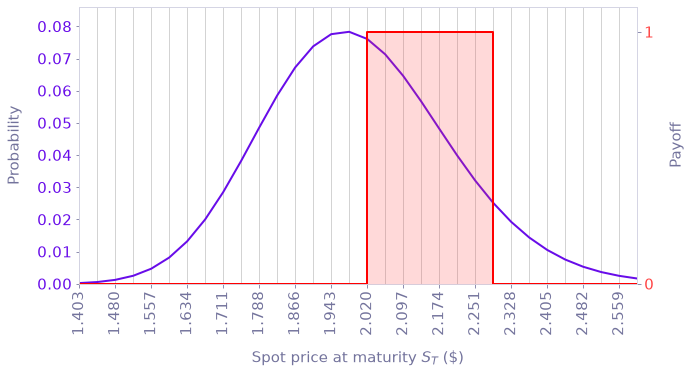

In [3]:
num_uncertainty_qubits = 5  # Number of qubits to discretize the distribution
S = 2.0  # Initial spot price
vol = 0.6  # Annualized volatility of 60%
r = 0.01  # Annual interest rate of 1%
T = 10 / 365  # 10 days to maturity

problem = EuropeanOptionPricing(
    spot_price=S, volatility=vol, interest_rate=r, maturity_years=T
)
visualize_option_pricing_problem(num_qubits=num_uncertainty_qubits, problem=problem)

## 5. Hardware demonstrations
To support different operational needs, Fire Opal offers two flexible execution configurations:

* **Quantum circuit workflow**: Ideal for developers who want to provide their own state preparation circuit, as we demonstrate for this use case by combining the distribution loading and payoff marking circuits.

* **Domain expert workflow**: Ideal for quantitative analysts who want to select probability distribution and objective function options directly without working with quantum circuits.

### 5.1 Run the function using the quantum circuit workflow
Our Monte Carlo integration function aims to estimate the probability of a particular outcome, which is encoded in a quantum state. Given a quantum state prepared by an operator $\mathcal{A}$ such that 
$$
\mathcal{A} \ket{0}^{\otimes n}\ket{0} = 
    \sqrt{1-p}\ket{\psi_0}\ket{0} + \sqrt{p}\ket{\psi_1}\ket{1},
$$
the function estimates the value $p$ which corresponds to the probability of measuring the ancilla qubit in state $\ket{1}$. Here $n$ denotes the number of bits to discretize the random variable, and $\braket{\psi_0\vert \psi_1} = 0$.  

To apply the function, you can provide the state preparation circuit that implements the operator $\mathcal{A}$. For our pricing problem example, we construct this circuit using distribution loading and payoff marking circuits. We use the ```LogNormalDistribution``` object from ```qiskit``` and a customized payoff marking circuit.

In [ ]:
def oracle(
    num_qubits: int, strike_window: tuple[float, float], high: float, low: float
) -> QuantumCircuit:
    """
    Creates the payoff marking circuit for our option pricing use case.

    Parameters
    ----------
    num_qubits : int
        The number of data qubits.
    strike_window : tuple[float, float]
        The low and high asset price for the option to pay out.
    high : float
        The maximum asset price to encode.
    low : float
        The minimum asset price to encode.

    Returns
    -------
    QuantumCircuit
        The quantum circuit to compute U|x>|y> = |x>|y + f(x) mod 2>,
        with n+1 qubits.
    """
    if strike_window[1] < high:
        is_window = True

    else:
        is_window = False

    slope = (2**num_qubits - 1) / (high - low)
    strike_window = [
        int(np.ceil(slope * (strike_price - low))) for strike_price in strike_window
    ]
    min_strike_bin = format(strike_window[0], f"0{num_qubits}b")[::-1]
    max_strike_bin = format(strike_window[1], f"0{num_qubits}b")[::-1]

    if is_window:
        flip_qubits = [
            i
            for i in range(len(max_strike_bin))
            if max_strike_bin[i] != min_strike_bin[i]
        ]
    else:
        flip_qubits = []

    control_qubits = [i for i in range(len(min_strike_bin)) if min_strike_bin[i] == "1"]

    qc = QuantumCircuit(num_qubits + 1)
    if is_window:
        qc.x(flip_qubits)
    qc.mcx(control_qubits + flip_qubits, num_qubits)
    if is_window:
        qc.x(flip_qubits)
    qc.name = "f(x)"
    return qc


def get_preparation_circuit(
    num_qubits: int, problem: EuropeanOptionPricing
) -> QuantumCircuit:
    """
    Construct the circuit to encode the target probability, for the MCI function input.

    Parameters
    ----------
    num_qubits: int
        Number of qubits to discretize the probability distribution.
    problem: EuropeanOptionPricing
        European option pricing problem.

    Returns
    -------
    QuantumCircuit
        State preparation circuit.
    """

    uncertainty_model = problem.get_uncertainty_model(num_qubits=num_qubits)
    high, low = problem.get_high_low()
    strike_window = problem.get_strike_window()

    spot_price = QuantumRegister(num_qubits, name="spot_price")
    output_qubit = QuantumRegister(1, name="output")
    circuit = QuantumCircuit(spot_price, output_qubit)

    circuit.compose(uncertainty_model, qubits=spot_price, inplace=True)
    circuit.barrier()
    circuit.compose(
        oracle(num_qubits=num_qubits, strike_window=strike_window, high=high, low=low),
        qubits=spot_price[:] + output_qubit[:],
        inplace=True,
    )
    circuit.barrier()

    return circuit

In [ ]:
max_iteration_count = 20

preparation_circuit = get_preparation_circuit(
    num_qubits=num_uncertainty_qubits, problem=problem
)

results_scenario_1 = fo.integrate_monte_carlo(
    problem={"preparation_circuit": dumps(preparation_circuit.decompose(reps=5))},
    integrator_options={
        "max_iteration_count": max_iteration_count,
        "full_output": True,
    },
    credentials=credentials,
    backend_name=backend_name,
)

This function performs multiple consecutive runs. Wait time may vary depending on hardware queues.



In [73]:
results_scenario_1.status()

{'status_message': 'Job has been submitted to Q-CTRL.',
 'action_status': 'STARTED'}

In [ ]:
estimates = [
    result["estimate"]
    for result in results_scenario_1.result()["metadata"]["iterations"]
]
variance = [
    result["variance"]
    for result in results_scenario_1.result()["metadata"]["iterations"]
]
iteration_count = [
    result["iteration_count"]
    for result in results_scenario_1.result()["metadata"]["iterations"]
]
evaluation_count = [
    result["evaluation_count"]
    for result in results_scenario_1.result()["metadata"]["iterations"]
]

In [6]:
@qctrl_style()
def plot_estimation_history(
    histories: dict,
    figure: Figure | None = None,
    known_value: float | None = None,
    x_axis_log: bool = False,
) -> None:
    """
    Plot the history of estimates and confidence intervals.

    Parameters
    ----------
    histories : dict[str, Any]
        A dictionary where keys are labels for different integrators
        and values are tuples of evaluation_counts, estimates, and variance.
    figure : Figure or None, optional
        A matplotlib Figure object for the plot. If None, a new figure is created,
        by default None.
    known_value : float or None, optional
        The known value of the integral, if known. If provided, a horizontal
        dashed line will be drawn at this value, by default None.
    x_axis_log : bool, optional
        If True, the x-axis will be set to a logarithmic scale, by default False.
    """
    figure = create_figure(figure)
    axes = figure.subplots(nrows=1, ncols=1)
    assert isinstance(axes, Axes)

    if known_value is not None:
        axes.axhline(
            known_value, linestyle="dashed", color="black", alpha=0.2, label="Known"
        )

    for label, (eval_count, estimate, variance) in histories.items():
        std_err = 1.96 * np.sqrt(variance)
        axes.fill_between(eval_count, estimate - std_err, estimate + std_err, alpha=0.1)
        axes.plot(eval_count, estimate, "o-", label=label, markersize=2, linewidth=1)

    axes.legend()
    if x_axis_log:
        axes.set_xscale("log")

    axes.set_xlabel("Evaluation count")
    axes.set_ylabel("Estimate")

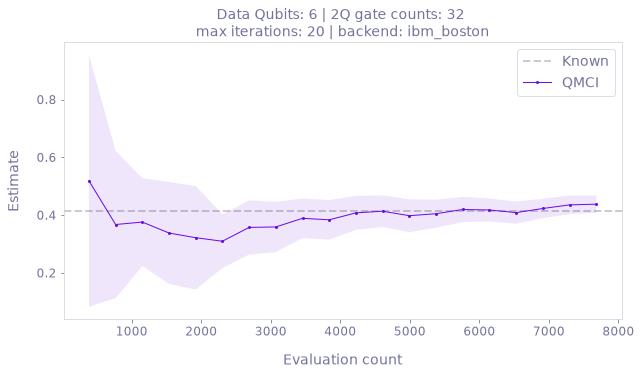

In [13]:
plot_estimation_history(
    histories={"QMCI": (evaluation_count, estimates, variance)},
    known_value=problem.get_exact_solution_with_discretized_values(
        num_uncertainty_qubits
    ),
)
plt.title(
    f'Data Qubits: {num_uncertainty_qubits+1} | 2Q gate counts: {preparation_circuit.decompose(reps=5).count_ops()["cx"]} \nmax iterations: {max_iteration_count} | backend: {backend_name}'
)
plt.show()

### 5.2 Run the function using the high-level domain expert workflow
For quantitative analysts, Fire Opal also accepts high-level specification objects directly. 
The function automatically synthesizes the operator $\mathcal{A}$ behind the scenes.

Fire Opal natively supports constructors for modeling diverse problem settings:

**Distribution constructors**:

* ```fireopal.make_lognormal_distribution```
* ```fireopal.make_normal_distribution```
* ```fireopal.make_uniform_distribution```
* ```fireopal.make_gci_model_distribution```

**Objective function constructors**:

* ```fireopal.make_european_call_delta_objective```
* ```fireopal.make_european_call_pricing_objective```
* ```fireopal.make_fixed_income_pricing_objective```

In this demonstration, we build the estimation problem using ```fireopal.make_lognormal_distribution``` to load the distribution and ```fireopal.make_european_call_delta_objective``` for the payoff marking.

In [15]:
high, low = problem.get_high_low()
strike_price = 2.05
num_uncertainty_qubits = 3
distribution = fo.make_lognormal_distribution(
    uncertainty=num_uncertainty_qubits,
    mu=problem.mu,
    sigma=problem.sigma**2,
    bounds=(low, high),
)
payoff_function = fo.make_european_call_delta_objective(
    bounds=(low, high), strike_price=strike_price
)


def get_exact_solution_delta_objective(
    num_qubits: int, problem: EuropeanOptionPricing, strike_price: float
):
    uncertainty_model = problem.get_uncertainty_model(num_qubits)
    return (
        np.exp(-problem.interest_rate * problem.maturity_years)
        * np.sum(
            uncertainty_model.probabilities[uncertainty_model.values > strike_price]
        ).item()
    )

In [ ]:
results_scenario_2 = fo.integrate_monte_carlo(
    problem=fo.make_monte_carlo_problem(
        objective_function_parameters=payoff_function,
        distribution_parameters=distribution,
    ),
    credentials=credentials,
    backend_name=backend_name,
    integrator_options={
        "max_iteration_count": max_iteration_count,
        "full_output": True,
    },
)

In [ ]:
estimates = [
    result["estimate"]
    for result in results_scenario_2.result()["metadata"]["iterations"]
]
variance = [
    result["variance"]
    for result in results_scenario_2.result()["metadata"]["iterations"]
]
iteration_count = [
    result["iteration_count"]
    for result in results_scenario_2.result()["metadata"]["iterations"]
]
evaluation_count = [
    result["evaluation_count"]
    for result in results_scenario_2.result()["metadata"]["iterations"]
]

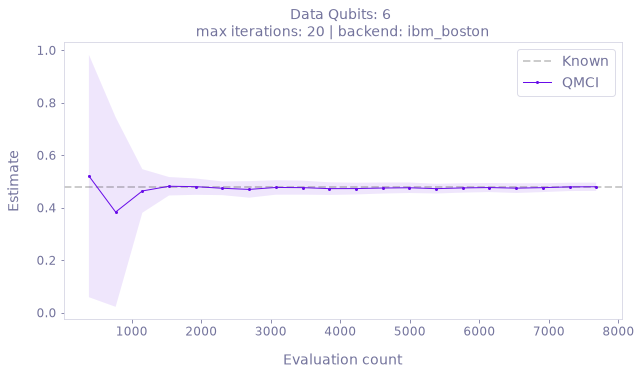

In [18]:
plot_estimation_history(
    histories={"QMCI": (evaluation_count, estimates, variance)},
    known_value=get_exact_solution_delta_objective(
        num_qubits=num_uncertainty_qubits, problem=problem, strike_price=strike_price
    ),
)
plt.title(
    f"Data Qubits: {num_uncertainty_qubits*2} \nmax iterations: {max_iteration_count} | backend: {backend_name}"
)
plt.show()

This notebook demonstrates the application of our quantum Monte Carlo integration solver to financial option pricing.
Our hardware-aware algorithm design and error suppression enable estimation of target values at novel problem scales and precision.
Fire Opal unlocks the application of quantum Monte Carlo for interesting use cases, and accelerates the advent of quantum-enhanced convergence in practical workflows.

In [72]:
from fireopal import print_package_versions

print_package_versions()

| Package               | Version     |
| --------------------- | ----------- |
| Python                | 3.11.15     |
| matplotlib            | 3.11.1      |
| networkx              | 3.6.1       |
| numpy                 | 2.4.6       |
| qiskit                | 2.4.1.post1 |
| qiskit-ibm-runtime    | 0.47.0      |
| sympy                 | 1.14.0      |
| fire-opal             | 12.1.1rc2   |
| qctrl-visualizer      | 10.1.0      |
| qctrl-workflow-client | 10.0.1      |
